<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo:

* María Daniela Rodríguez Chacón
mdaniela.rodriguez@udea.edu.co

* David Agudelo Ochoa
david.agudeloo@udea.edu.co


# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

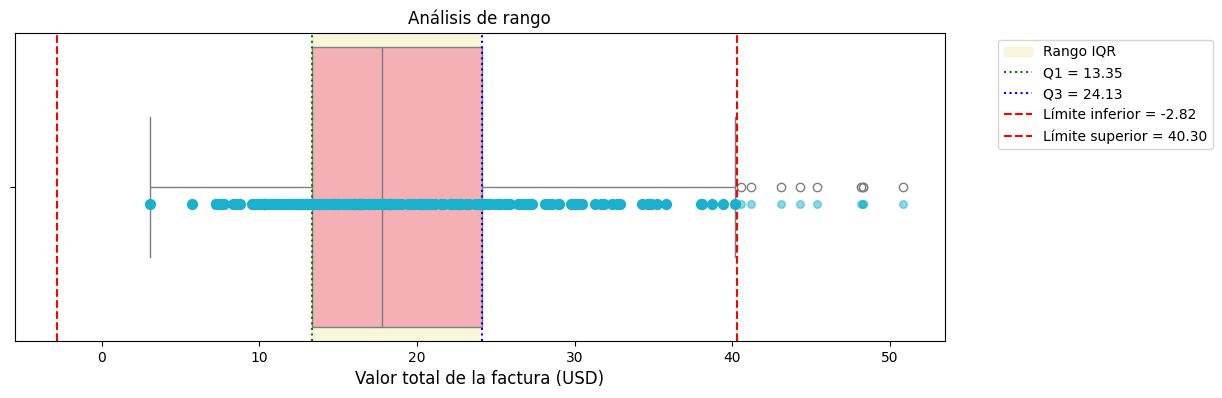

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]


plt.figure(figsize=(12,4))
sns.boxplot(x=total_bill, color="#ffa5aa")
plt.axvspan(Q1, Q3, color='#ebe68d', alpha=0.3, label='Rango IQR')
plt.axvline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.scatter(data_a, [0.05]*len(data_a), color="#1bb0ce", s=30, alpha=0.5)
plt.scatter(data_b, [0.05]*len(data_b), color="#1bb0ce", s=50, zorder=5)
plt.title("Análisis de rango")
plt.xlabel("Valor total de la factura (USD)", fontsize=12)
plt.show()


#### Análisis

Los puntos fuera de los límites (inferior y superior) son identificados como valores atípicos. La distribución muestra una ligera asimetría a la derecha, con atípicos solo en el extremo superior.
Los atípicos superiores sugieren facturas altas que podrían requerir investigación adicional.



# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

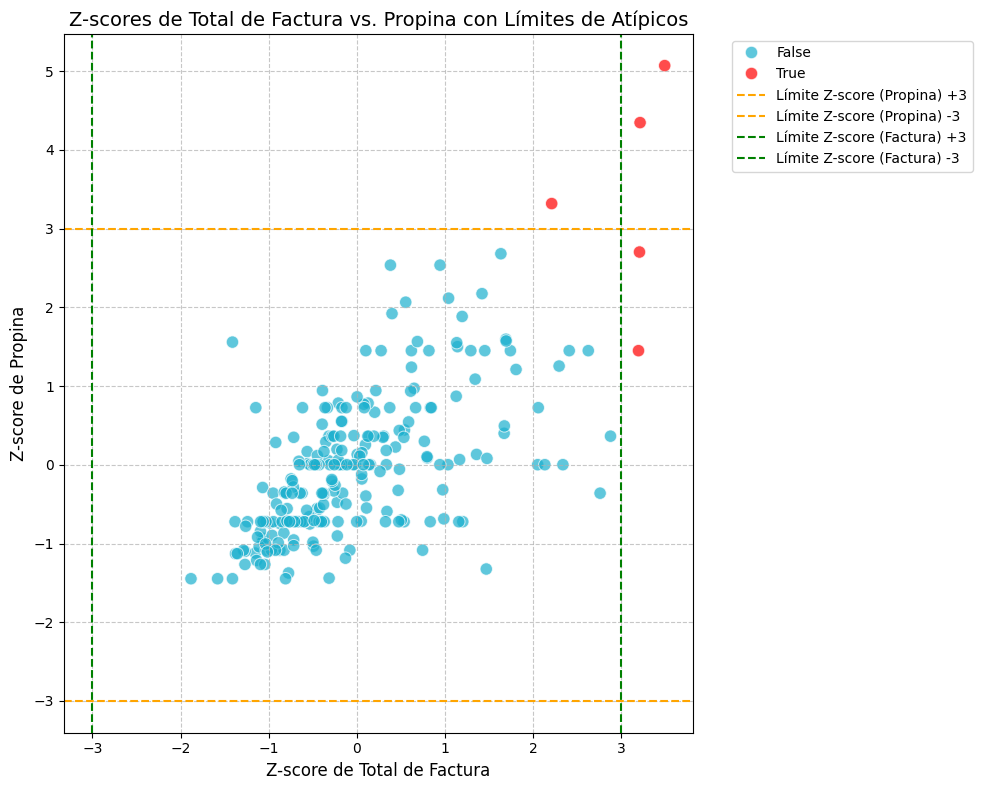

In [17]:
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

tips = sns.load_dataset("tips")

tips['z_score_total_bill'] = zscore(tips['total_bill'])
tips['z_score_tip'] = zscore(tips['tip'])

tips['is_outlier_total_bill'] = tips['z_score_total_bill'].abs() > 3
tips['is_outlier_tip'] = tips['z_score_tip'].abs() > 3
tips['is_bivariate_outlier'] = tips['is_outlier_total_bill'] | tips['is_outlier_tip']

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='z_score_total_bill',
    y='z_score_tip',
    data=tips,
    hue='is_bivariate_outlier',
    palette={False: '#1bb0ce', True: 'red'},
    s=80,
    alpha=0.7
)

#Línea horizontal para la variable 'tips' con los umbrales de z-score
plt.axhline(y=3, color='orange', linestyle='--', label='Límite Z-score (Propina) +3')
plt.axhline(y=-3, color='orange', linestyle='--', label='Límite Z-score (Propina) -3')

#Línea vertical para la variable 'tips' con los umbrales de z-score
plt.axvline(x=3, color='green', linestyle='--', label='Límite Z-score (Factura) +3')
plt.axvline(x=-3, color='green', linestyle='--', label='Límite Z-score (Factura) -3')

plt.title('Z-scores de Total de Factura vs. Propina con Límites de Atípicos', fontsize=14)
plt.xlabel('Z-score de Total de Factura', fontsize=12)
plt.ylabel('Z-score de Propina', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Análisis

Encontramos dos datos atípicos para `bill` y `total_bill`, indicando que son valores atípicos multivariados, ya que sobrepasan el límite de más o menos 3 en ambas variables. La posición de estos atípicos sugiere una correlación positiva, donde propinas y facturas altas pueden ocurrir juntas, reforzando la relación entre ambas variables.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

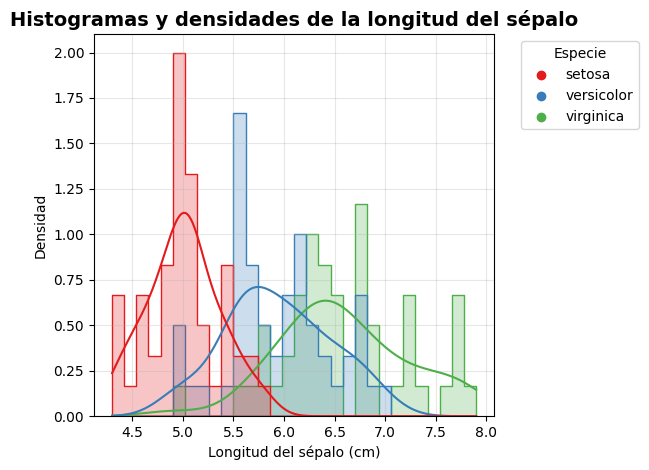

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values
species = iris["species"].unique()

palette = dict(zip(species, sns.color_palette("Set1", n_colors=len(species))))

# Histograma
ax = sns.histplot(
    data=iris,
    x="sepal_length",
    hue="species",
    kde=True,
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    palette=palette,
    legend=False
)

plt.title("Histogramas y densidades de la longitud del sépalo", fontsize=14, weight="bold")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Densidad")

for sp in species:
    ax.scatter([], [], color=palette[sp], label=sp)

ax.legend(title="Especie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Análisis

La distribución de Iris setosa es bastante compacta y no muestra valores claramente atípicos, mientras que Iris versicolor presenta mayor dispersión con posibles atípicos leves en los extremos. Iris virginica exhibe la mayor variabilidad, con algunos valores altos que podrían considerarse atípicos, especialmente en la cola superior, aunque el solapamiento entre especies dificulta identificarlos con total claridad.



# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

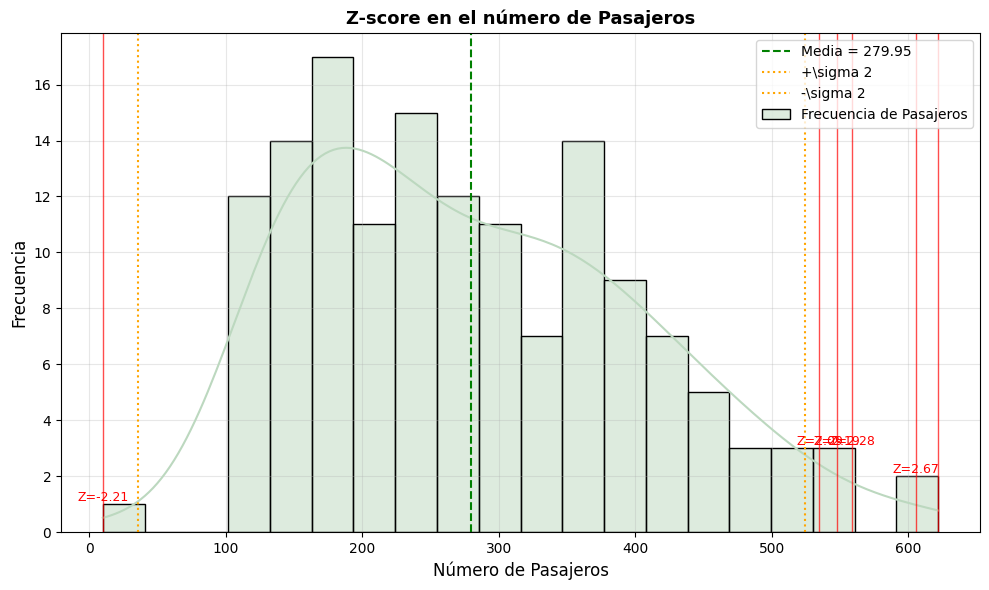

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

flights = sns.load_dataset("flights")
x = flights["passengers"].values
x = np.append(x, [10, 500])

data = x

plt.figure(figsize=(10, 6))

# Calcular Z-scores
z_scores = stats.zscore(data)

outlier_threshold = 2
outliers_data = data[np.abs(z_scores) > outlier_threshold]
outliers_z = z_scores[np.abs(z_scores) > outlier_threshold]

# Histograma
sns.histplot(data, bins=20, kde=True, color='#bcd8bf', label='Frecuencia de Pasajeros')

# Líneas de referencia para la media y desviaciones estándar
mean_val = np.mean(data)
std_val = np.std(data)
plt.axvline(mean_val, color="green", linestyle="--", label=f"Media = {mean_val:.2f}")
plt.axvline(mean_val + outlier_threshold*std_val, color="orange", linestyle=":", label=f"+\\sigma {outlier_threshold}")
plt.axvline(mean_val - outlier_threshold*std_val, color="orange", linestyle=":", label=f"-\\sigma {outlier_threshold}")

# Outliers con anotación de Z-score
n, bins, patches = plt.gca().hist(data, bins=20, alpha=0)

for out_val, z_val in zip(outliers_data, outliers_z):
    bin_idx = np.digitize(out_val, bins) - 1
    if bin_idx < len(n):
        y_pos = n[bin_idx] if n[bin_idx] > 0 else plt.gca().get_ylim()[1]
        plt.text(out_val, y_pos, f"Z={z_val:.2f}", color="red", fontsize=9, ha='center', va='bottom')
    plt.axvline(out_val, color="red", linestyle="-", linewidth=1, alpha=0.7)

plt.title(f"Z-score en el número de Pasajeros", fontsize=13, weight="bold")
plt.xlabel("Número de Pasajeros", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Análisis
Aunque la gráfica muestra valores atípicos en ambos extremos, la mayor concentración se encuentra en la cola derecha, lo que indica una distribución con asimetría positiva. Además, se observa que el valor máximo del Z-score no supera 3, por lo que utilizar este umbral sería poco sensible para detectar outliers en este caso. Por esta razón, se decidió ajustar el umbral a 2, permitiendo una identificación más adecuada de los datos atípicos.

In [20]:
flights["passengers"].values

array([112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118, 115,
       126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140, 145, 150,
       178, 163, 172, 178, 199, 199, 184, 162, 146, 166, 171, 180, 193,
       181, 183, 218, 230, 242, 209, 191, 172, 194, 196, 196, 236, 235,
       229, 243, 264, 272, 237, 211, 180, 201, 204, 188, 235, 227, 234,
       264, 302, 293, 259, 229, 203, 229, 242, 233, 267, 269, 270, 315,
       364, 347, 312, 274, 237, 278, 284, 277, 317, 313, 318, 374, 413,
       405, 355, 306, 271, 306, 315, 301, 356, 348, 355, 422, 465, 467,
       404, 347, 305, 336, 340, 318, 362, 348, 363, 435, 491, 505, 404,
       359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463, 407,
       362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390,
       432])

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

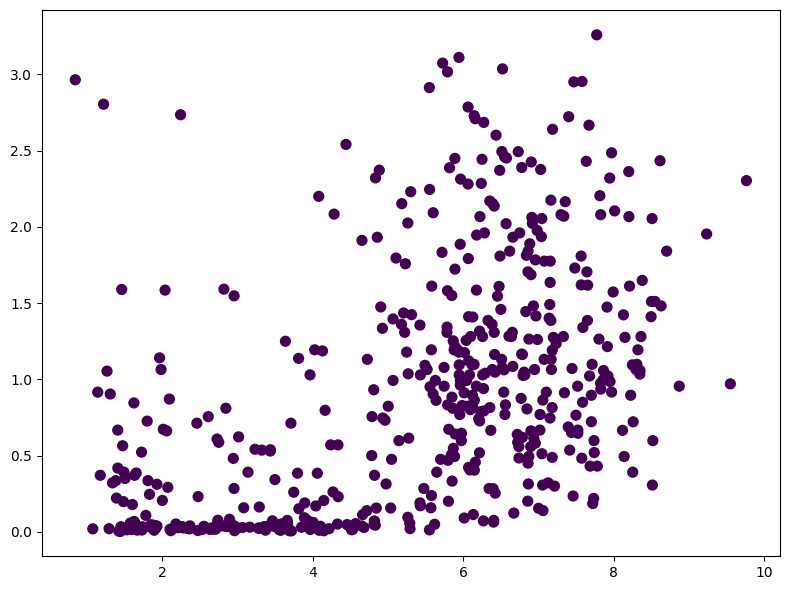

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=1, random_state=42).fit(X)
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50)
plt.tight_layout()
plt.show()
